# 🌿 AI-Based Plant Disease Detection Using CNN
### Project by: [Your Name] | College: [Your College Name]

---
**Objective:** Classify tomato leaf images into 3 categories:
- ✅ Tomato Healthy
- 🟡 Tomato Early Blight
- 🔴 Tomato Late Blight

**Dataset:** PlantVillage Dataset (available on Kaggle)

**Tech Stack:** Python, TensorFlow/Keras, OpenCV, Matplotlib

## Step 1: Install & Import Required Libraries

In [1]:
# ─── Install if not already installed ───
# !pip install tensorflow opencv-python matplotlib numpy scikit-learn

# ─── Standard Library Imports ───
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

# ─── OpenCV for image processing ───
import cv2

# ─── TensorFlow / Keras for Deep Learning ───
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import load_img, img_to_array

# ─── Scikit-learn for metrics ───
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ All libraries imported successfully!
TensorFlow version: 2.21.0


## Step 2: Define Dataset Paths & Configuration

**Dataset Folder Structure Required:**
```
dataset/
├── train/
│   ├── Tomato_healthy/
│   ├── Tomato_Early_blight/
│   └── Tomato_Late_blight/
└── test/
    ├── Tomato_healthy/
    ├── Tomato_Early_blight/
    └── Tomato_Late_blight/
```
> 📥 Download PlantVillage from: https://www.kaggle.com/datasets/emmarex/plantdisease

In [2]:
# ─── Configuration ───
IMG_SIZE    = 128          # Resize all images to 128x128 pixels
BATCH_SIZE  = 32           # Number of images per training batch
EPOCHS      = 20           # Number of times model sees full dataset
NUM_CLASSES = 3            # Healthy, Early Blight, Late Blight

# ─── Dataset Paths ───
TRAIN_DIR = 'dataset/train'
TEST_DIR  = 'dataset/test'

# ─── Class Names ───
CLASS_NAMES = ['Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_healthy']

print("✅ Configuration set!")
print(f"Image Size   : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size   : {BATCH_SIZE}")
print(f"Epochs       : {EPOCHS}")
print(f"Classes      : {NUM_CLASSES}")

✅ Configuration set!
Image Size   : 128x128
Batch Size   : 32
Epochs       : 20
Classes      : 3


## Step 3: Data Preprocessing & Augmentation

**Why Data Augmentation?**
- Artificially increases dataset size
- Helps model generalize better (avoid overfitting)
- Applies random flips, rotations, zooms to training images

In [3]:
# ─── Training Data Generator (with Augmentation) ───
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values from [0-255] to [0-1]
    rotation_range=20,       # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2,   # Shift images horizontally
    height_shift_range=0.2,  # Shift images vertically
    shear_range=0.2,         # Shear transformation
    zoom_range=0.2,          # Randomly zoom in/out
    horizontal_flip=True,    # Flip images horizontally
    fill_mode='nearest'      # Fill empty areas after rotation
)

# ─── Test Data Generator (only rescaling, NO augmentation) ───
test_datagen = ImageDataGenerator(rescale=1./255)

# ─── Load Training Data ───
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),  # Resize all images
    batch_size=BATCH_SIZE,
    class_mode='categorical'           # One-hot encoding for 3 classes
)

# ─── Load Test Data ───
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False                      # Keep order for evaluation
)

print("\n✅ Data loaded successfully!")
print(f"Training samples  : {train_generator.samples}")
print(f"Testing samples   : {test_generator.samples}")
print(f"Class indices     : {train_generator.class_indices}")

Found 1200 images belonging to 3 classes.
Found 300 images belonging to 3 classes.

✅ Data loaded successfully!
Training samples  : 1200
Testing samples   : 300
Class indices     : {'Tomato_Early_blight': 0, 'Tomato_Late_blight': 1, 'Tomato_healthy': 2}


## Step 4: Visualize Sample Training Images

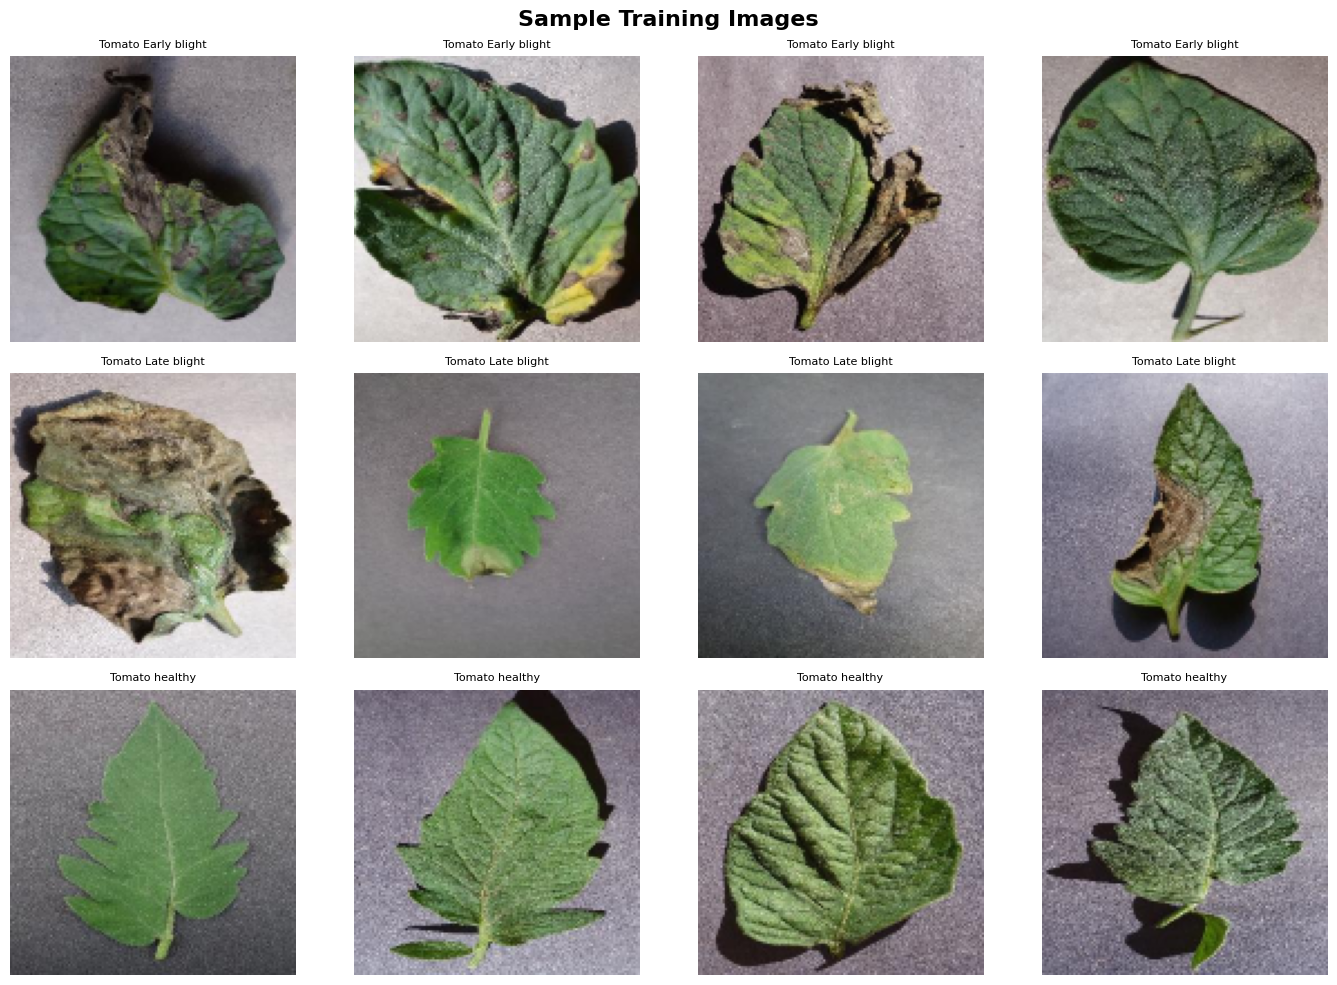

✅ Sample images displayed!


In [4]:
# ─── Show Sample Images from Each Class ───
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Sample Training Images', fontsize=16, fontweight='bold')

class_list = list(train_generator.class_indices.keys())

for row, class_name in enumerate(class_list):
    class_path = os.path.join(TRAIN_DIR, class_name)
    images = os.listdir(class_path)[:4]  # Show 4 images per class
    
    for col, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name.replace('_', ' '), fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100)
plt.show()
print("✅ Sample images displayed!")

## Step 5: Build the CNN Model

### CNN Architecture Explanation:
| Layer | Purpose |
|-------|----------|
| **Conv2D** | Extracts features (edges, textures, patterns) from image |
| **BatchNormalization** | Normalizes outputs for faster, stable training |
| **MaxPooling2D** | Reduces image size while keeping important features |
| **Dropout** | Randomly turns off neurons to prevent overfitting |
| **Flatten** | Converts 2D feature maps into 1D vector |
| **Dense** | Fully connected layer for final classification |

In [5]:
# ─── Build CNN Model ───
model = Sequential([

    # ── Block 1: First Convolutional Block ──
    # 32 filters of size 3x3, extract basic features like edges
    Conv2D(32, (3, 3), activation='relu', padding='same',
           input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),     # Reduce from 128x128 → 64x64

    # ── Block 2: Second Convolutional Block ──
    # 64 filters, learn more complex patterns
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),     # Reduce from 64x64 → 32x32
    Dropout(0.25),                      # Drop 25% neurons randomly

    # ── Block 3: Third Convolutional Block ──
    # 128 filters, detect disease-specific patterns
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),     # Reduce from 32x32 → 16x16
    Dropout(0.25),

    # ── Flatten: Convert 2D → 1D ──
    Flatten(),                          # 16x16x128 → 32768 values

    # ── Fully Connected Layers ──
    Dense(256, activation='relu'),      # Learn abstract combinations
    BatchNormalization(),
    Dropout(0.5),                       # Drop 50% to prevent overfitting

    # ── Output Layer ──
    # 3 neurons (one per class), softmax gives probability for each class
    Dense(NUM_CLASSES, activation='softmax')
])

# ─── Compile the Model ───
model.compile(
    optimizer='adam',                       # Adam optimizer - works well in most cases
    loss='categorical_crossentropy',        # Loss function for multi-class classification
    metrics=['accuracy']                    # Track accuracy during training
)

# ─── Print Model Summary ───
model.summary()
print("\n✅ CNN Model built successfully!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,803 (32.37 MB)

 Trainable params: 8,483,843 (32.36 MB)

 Non-trainable params: 960 (3.75 KB)


✅ CNN Model built successfully!


## Step 6: Train the Model

In [6]:
# ─── Callbacks ───
# EarlyStopping: Stop training if validation accuracy doesn't improve
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,              # Wait 5 epochs before stopping
    restore_best_weights=True
)

# ModelCheckpoint: Save best model during training
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# ─── Train the Model ───
print("🚀 Training started...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\n✅ Training complete!")

🚀 Training started...
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.6612 - loss: 1.1561
Epoch 1: val_accuracy improved from None to 0.33333, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 36s 838ms/step - accuracy: 0.7400 - loss: 0.7918 - val_accuracy: 0.3333 - val_loss: 4.8488
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 986ms/step - accuracy: 0.8350 - loss: 0.4020
Epoch 2: val_accuracy improved from 0.33333 to 0.58000, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8433 - loss: 0.3841 - val_accuracy: 0.5800 - val_loss: 1.3666
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - accuracy: 0.8531 - loss: 0.3686
Epoch 3: val_accuracy did not improve from 0.58000
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 848ms/step - accuracy: 0.8733 - loss: 0.3191 - val_accuracy: 0.3533 - val_loss: 3.8995
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.9009 - loss: 0.2592
Epoch 4: val_accuracy did not improve from 0.58000
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 589ms/step - accuracy: 0.9025 - loss: 0.2697 - val_accuracy: 0.3333 - val_loss: 6.7844
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.8668 - loss: 0.3360
Epoch 5: val_accuracy did not improve from 0.58000
38/38 ━━━━━━━━━━━━━━━━━━━━ 26s 674ms/step - accuracy: 0.8833 - loss: 0.2977 - val_accuracy: 0.4700 - val_loss: 3.4413
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.8875 


Epoch 7: finished saving model to best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 588ms/step - accuracy: 0.8750 - loss: 0.3134 - val_accuracy: 0.5900 - val_loss: 1.5756
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.8937 - loss: 0.2531
Epoch 8: val_accuracy did not improve from 0.59000
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 597ms/step - accuracy: 0.8992 - loss: 0.2605 - val_accuracy: 0.3300 - val_loss: 3.4844
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.9100 - loss: 0.2199
Epoch 9: val_accuracy improved from 0.59000 to 0.61667, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 593ms/step - accuracy: 0.9150 - loss: 0.2376 - val_accuracy: 0.6167 - val_loss: 1.1757
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.9234 - loss: 0.2094
Epoch 10: val_accuracy improved from 0.61667 to 0.66333, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 586ms/step - accuracy: 0.9050 - loss: 0.2485 - val_accuracy: 0.6633 - val_loss: 0.8232
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.8949 - loss: 0.2580
Epoch 11: val_accuracy improved from 0.66333 to 0.67667, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 599ms/step - accuracy: 0.8892 - loss: 0.2775 - val_accuracy: 0.6767 - val_loss: 0.9299
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.9012 - loss: 0.2379
Epoch 12: val_accuracy did not improve from 0.67667
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 607ms/step - accuracy: 0.9058 - loss: 0.2481 - val_accuracy: 0.6700 - val_loss: 0.9300
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.9092 - loss: 0.2302
Epoch 13: val_accuracy improved from 0.67667 to 0.73667, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 593ms/step - accuracy: 0.9133 - loss: 0.2181 - val_accuracy: 0.7367 - val_loss: 1.1868
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.9053 - loss: 0.2122
Epoch 14: val_accuracy did not improve from 0.73667
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 585ms/step - accuracy: 0.9075 - loss: 0.2179 - val_accuracy: 0.6267 - val_loss: 1.4543
Epoch 15/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.8984 - loss: 0.2402
Epoch 15: val_accuracy improved from 0.73667 to 0.88333, saving model to best_model.h5



Epoch 15: finished saving model to best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 589ms/step - accuracy: 0.9017 - loss: 0.2300 - val_accuracy: 0.8833 - val_loss: 0.2823
Epoch 16/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.9077 - loss: 0.2004
Epoch 16: val_accuracy did not improve from 0.88333
38/38 ━━━━━━━━━━━━━━━━━━━━ 24s 638ms/step - accuracy: 0.9117 - loss: 0.2056 - val_accuracy: 0.8667 - val_loss: 0.3145
Epoch 17/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.9192 - loss: 0.1943
Epoch 17: val_accuracy did not improve from 0.88333
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 587ms/step - accuracy: 0.9233 - loss: 0.2089 - val_accuracy: 0.4533 - val_loss: 4.0294
Epoch 18/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.9256 - loss: 0.1839
Epoch 18: val_accuracy improved from 0.88333 to 0.90333, saving model to best_model.h5



Epoch 18: finished saving model to best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 586ms/step - accuracy: 0.9325 - loss: 0.1691 - val_accuracy: 0.9033 - val_loss: 0.2945
Epoch 19/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.9363 - loss: 0.1815
Epoch 19: val_accuracy did not improve from 0.90333
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 577ms/step - accuracy: 0.9350 - loss: 0.1825 - val_accuracy: 0.8600 - val_loss: 0.2856
Epoch 20/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.9394 - loss: 0.1433
Epoch 20: val_accuracy did not improve from 0.90333
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 576ms/step - accuracy: 0.9375 - loss: 0.1634 - val_accuracy: 0.7733 - val_loss: 0.6141

✅ Training complete!


## Step 7: Plot Training Results (Accuracy & Loss Graphs)

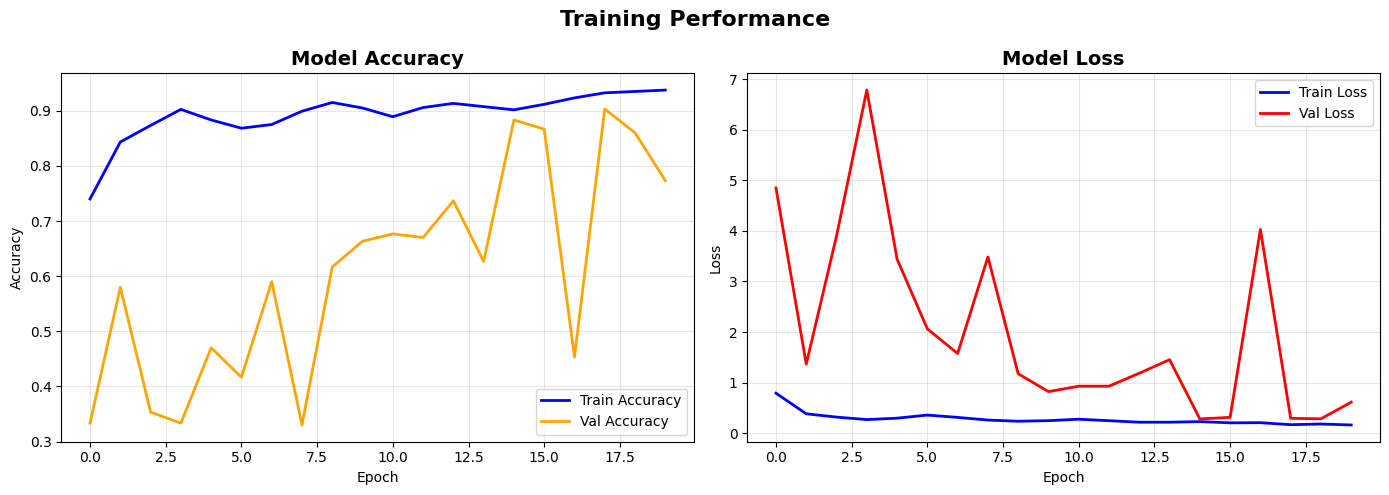

✅ Training graphs saved!


In [7]:
# ─── Plot Accuracy and Loss Curves ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy Plot ---
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='blue',  linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Loss Plot ---
axes[1].plot(history.history['loss'],     label='Train Loss', color='blue',  linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='red',   linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Performance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_graphs.png', dpi=100)
plt.show()
print("✅ Training graphs saved!")

## Step 8: Evaluate the Model on Test Data

In [8]:
# ─── Load Best Saved Model ───
from tensorflow.keras.models import load_model
best_model = load_model('best_model.h5')

# ─── Evaluate on Test Set ───
test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=1)
print(f"\n📊 Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"📊 Test Loss     : {test_loss:.4f}")

# ─── Predictions ───
test_generator.reset()
predictions = best_model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes      = test_generator.classes
class_labels      = list(test_generator.class_indices.keys())

# ─── Classification Report ───
print("\n📋 Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9033 - loss: 0.2945

📊 Test Accuracy : 90.33%
📊 Test Loss     : 0.2945
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step

📋 Classification Report:
                     precision    recall  f1-score   support

Tomato_Early_blight       0.90      0.93      0.92       100
 Tomato_Late_blight       0.95      0.78      0.86       100
     Tomato_healthy       0.87      1.00      0.93       100

           accuracy                           0.90       300
          macro avg       0.91      0.90      0.90       300
       weighted avg       0.91      0.90      0.90       300



## Step 9: Confusion Matrix

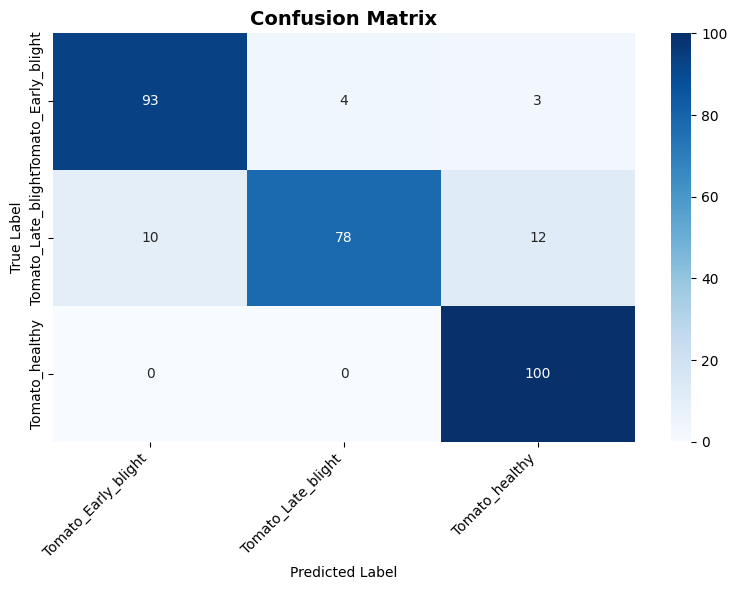

✅ Confusion matrix saved!


In [9]:
# ─── Plot Confusion Matrix ───
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()
print("✅ Confusion matrix saved!")

## Step 10: Save the Final Model

In [10]:
# ─── Save the trained model as .h5 file ───
# .h5 format stores model architecture + weights + training config
best_model.save('plant_disease_model.h5')
print("✅ Model saved as 'plant_disease_model.h5'")

# ─── Save class indices for use in Flask app ───
import json
class_indices = train_generator.class_indices
# Invert dict: {0: 'class_name', 1: 'class_name', ...}
idx_to_class = {v: k for k, v in class_indices.items()}

with open('class_indices.json', 'w') as f:
    json.dump(idx_to_class, f)

print("✅ Class indices saved as 'class_indices.json'")
print(f"Class mapping: {idx_to_class}")

✅ Model saved as 'plant_disease_model.h5'
✅ Class indices saved as 'class_indices.json'
Class mapping: {0: 'Tomato_Early_blight', 1: 'Tomato_Late_blight', 2: 'Tomato_healthy'}


## Step 11: Predict a Single New Image

In [11]:
def predict_image(image_path, model, class_indices):
    """
    Predict the disease class for a single leaf image.
    
    Args:
        image_path: Path to the image file
        model: Trained Keras model
        class_indices: Dict mapping index to class name
    
    Returns:
        Predicted class name and confidence percentage
    """
    # ── Load and preprocess image ──
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)      # Convert to numpy array
    img_array = img_array / 255.0      # Normalize to [0, 1]
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension: (1, 128, 128, 3)

    # ── Make Prediction ──
    predictions = model.predict(img_array, verbose=0)
    predicted_idx = np.argmax(predictions[0])       # Get index of highest probability
    confidence    = predictions[0][predicted_idx] * 100  # Convert to percentage
    predicted_class = class_indices[str(predicted_idx)]

    # ── Display Result ──
    plt.figure(figsize=(6, 5))
    img_display = cv2.imread(image_path)
    img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
    plt.imshow(img_display)
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}%",
              fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return predicted_class, confidence


# ─── Test with a sample image ───
# Change this path to any leaf image on your system
TEST_IMAGE_PATH = 'dataset/test/Tomato_healthy/sample.jpg'

if os.path.exists(TEST_IMAGE_PATH):
    result_class, result_conf = predict_image(TEST_IMAGE_PATH, best_model, idx_to_class)
    print(f"\n🔍 Prediction  : {result_class}")
    print(f"📊 Confidence  : {result_conf:.2f}%")
else:
    print("⚠️  Test image not found. Change TEST_IMAGE_PATH to a valid leaf image.")

⚠️  Test image not found. Change TEST_IMAGE_PATH to a valid leaf image.
